<h1>Monstro da Semana 8: Elemental do Ar</h1>

<h4><i>- Bruno Bini Camargo</i></h4>

<h2>Introdução</h2>

Neste exercício, serão utilizadas duas abordagens para a realização de testes de hipóteses.

A primeira abordagem consiste em um teste baseado em simulação, no qual um modelo é construído sob a hipótese nula e utilizado para gerar amostras artificiais. A partir dessas simulações, é possível avaliar o quão compatíveis os dados observados são com o modelo proposto. A segunda abordagem consiste em um teste analítico de aderência Qui-Quadrado, que utiliza resultados teóricos da estatística para comparar frequências observadas e esperadas.

Ao final, os resultados obtidos por ambas as abordagens serão comparados e interpretados.

<h2>Desenvolvimento</h2>

<h3>Enunciado</h3>

**1. Contextualização**
   
O efeito da idade relativa (EIR) é um fenômeno bem documentado no esporte: atletas nascidos logo após a data de corte das categorias de base tendem a ser sistematicamente super‑representados em categorias profissionais. O motivo é que, nas categorias jovens, meses de diferença de idade representam vantagens físicas significativas, levando treinadores a selecionar preferenciamente os nascidos no início do ano. No Brasil, o corte para categorias de base no futebol é $1$ de janeiro. Se o EIR não existisse, esperaríamos que os nascimentos dos jogadores profissionais seguissem a distribuição geral de nascimentos no Brasil, que é aproximadamente uniforme entre os trimestres do ano ($25\%$ por trimestre).

**2. Objetivo**
   
Você coletou os dados de nascimento de 400 jogadores de uma liga de futebol 
profissional brasileiro e obteve a seguinte distribuição por trimestre:
- Nascidos no $1°$ trimestre: $148$ jogadores
- Nascidos no $2°$ trimestre: $112$ jogadores
- Nascidos no $3°$ trimestre: $90$ jogadores
- Nascidos no $4°$ trimestre: $50$ jogadores
  
A partir desta observação, você levantou as seguintes hipóteses:
- $H_0$: a distribuição de jogadores na liga de futebol estudada segue a distribuição de nascimentos no Brasil.
- $H_1$: a distribuição de jogadores na liga de futebol estudada não segue a distribuição de nascimentos no Brasil.
  
**Teste por simulação:**

1 - Calcule a estatística de teste observada (TVD entre a distribuição observada e a distribuição do modelo).

2 - Simule pelo menos $10000$ experimentos sob $H_0$ e obtenha a distribuição de probabilidades da estatística de teste.

3 - Plote a distribuição obtida e indique visualmente onde está a estatística de teste observada.

4 - Calcule o p‑valor e chegue a uma conclusão fundamentada. O que exatamente conseguimos concluir com este teste?

**Teste analítico:**

1 - Use o teste de aderência qui‑quadrado para obter o p‑valor analiticamente.

2 - Compare o p‑valor obtido analiticamente com o obtido por simulação. Eles são próximos? O que você pode concluir com esta observação?

<h3>Resolução</h3>

Para a resolução desse exercício, vamos adotar um nível de significância de $5\%$, o que significa aceitar um risco máximo de $5\%$ de rejeitar a hipótese nula quando ela é verdadeira (Erro Tipo I - falso positivo).

<h4>Teste por simulação</h4>

O enunciado fornece a quantidade de jogadores nascidos em cada trimestre do ano. Para realizar o teste por simulação, primeiro vamos organizar os valores observados.

In [1]:
import pandas as pd

dados = {
    'Trimestre': ['1º', '2º', '3º', '4º'],
    'Jogadores': [148, 112, 90, 50]
}

df = pd.DataFrame(dados)

print(
    df.to_string(
        index=False,
        justify = "center",
        col_space = 15, 
    )
)

   Trimestre        Jogadores  
       1º             148      
       2º             112      
       3º              90      
       4º              50      


O total analisado é de $400$ jogadores. A hipótese nula afirma que os nascimentos estão uniformemente distribuídos entre os quatro trimestres, ou seja, espera-se que cada trimestre contenha $25\%$ dos jogadores. Assim, a distribuição esperada é de $(100, 100, 100, 100)$.

Vamos agora converter as frequências absolutas em frequências relativas. As frequências relativas observadas serão comparadas com as frequências esperadas sob $H_0$.

In [2]:
import numpy as np

observado = np.array([148, 112, 90, 50])

esperado = np.array([100, 100, 100, 100])

n = observado.sum()

freq_obs = observado / n
freq_esp = esperado / n

print("Distribuição observada:")
print(freq_obs)

print("\nDistribuição esperada:")
print(freq_esp)

Distribuição observada:
[0.37  0.28  0.225 0.125]

Distribuição esperada:
[0.25 0.25 0.25 0.25]


Observa-se que o primeiro trimestre apresenta proporção superior ao esperado, enquanto o quarto trimestre apresenta proporção inferior. Entretanto, ainda não sabemos se essas diferenças são suficientemente grandes para rejeitar $H_0$.

Para responder a essa questão utilizaremos a estatística $\text{TVD}$ (Distância de Variação Total), que mede o quão diferentes são duas distribuições de probabilidade.

A $\text{TVD}$ é definida por

$$\text{TVD} = \frac{1}{2}\sum |p_i - q_i|$$

onde: 
- $p_i$ representa as proporções observadas
- $q_i$ representa as proporções esperadas sob $H_0$

Quanto maior o valor da $\text{TVD}$, maior será a discrepância entre os dados e a hipótese nula. Ou seja, quando $\text{TVD} = 0$, as distribuições são idênticas e, quando $\text{TVD} = 1$, está representada a maior discrepância possível.

Substituindo as distribuições observada e esperada na fórmula:

$$TVD = \frac{1}{2}(|0.370-0.250|+|0.280-0.250|+|0.225-0.250|+|0.125-0.250|)$$
$$=\frac{1}{2}(0.120+0.030+0.025+0.125) =\frac{0.300}{2}=0.15$$
Portanto, a estatística observada é igual a $0.15$.

Em Python, temos:

In [3]:
import numpy as np

def tvd(obs, esp):
    diferencas = abs(np.array(obs) - np.array(esp))
    return np.sum(diferencas) / 2

In [4]:
tvd_obs = tvd(
    freq_obs,
    freq_esp
)

print(f"TVD observada: {tvd_obs:.2f}")

TVD observada: 0.15


O valor da $\text{TVD}$ observado, isoladamente, não permite determinar se a discrepância encontrada é incomum sob $H_0$. Para isso, precisamos compará-lo com a distribuição da $\text{TVD}$ obtida a partir de simulações do modelo nulo.

Para isso construiremos um modelo de simulação em que:
- existem $400$ jogadores
- cada jogador possui probabilidade de $25\%$ de nascer em qualquer trimestre

A partir desse modelo realizaremos $10000$ simulações. Em cada repetição, será gerada uma amostra de $400$ jogadores, calculadas as frequências relativas e a $\text{TVD}$ da amostra, e armazenado o resultado.

In [5]:
n_sim = 10000

tvd_sim = np.zeros(n_sim)

for i in range(n_sim):

    amostra = np.random.multinomial(
        n=400,
        pvals=[0.25, 0.25, 0.25, 0.25]
    )

    freq_amostra = amostra / 400

    tvd_sim[i] = tvd(
        freq_amostra,
        freq_esp
    )

Agora que as $10000$ simulações foram concluídas, podemos examinar, no histograma abaixo, a distribuição dos valores de $\text{TVD}$ obtidos quando a hipótese nula é verdadeira. A linha vermelha representa a $\text{TVD}$ observada nos dados reais:

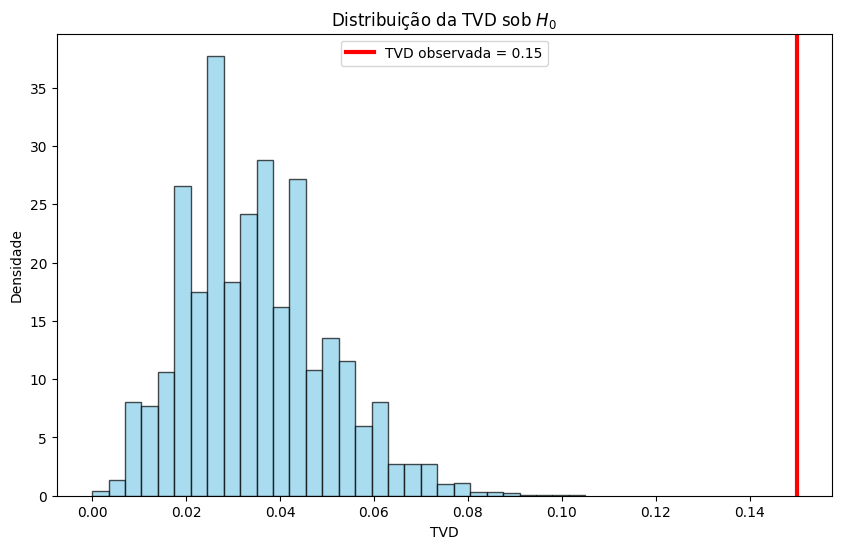

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    tvd_sim,
    bins=30,
    density=True,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)

plt.axvline(
    tvd_obs,
    color='red',
    linewidth=3,
    label=f'TVD observada = {tvd_obs:.2f}'
)

plt.title("Distribuição da TVD sob $H_0$")
plt.xlabel("TVD")
plt.ylabel("Densidade")
plt.legend()

plt.show()

No gráfico acima, observa-se que a maior parte dos valores simulados de $\text{TVD}$ encontra-se abaixo de aproximadamente $0.08$. Já a $\text{TVD}$ observada ($0.15$) ficou muito acima do esperado pelo acaso, mostrando que a diferença entre os dados reais e o modelo de $H_0$ é estatisticamente significativa.

Agora, de forma a se aprofundar mais na análise, vamos calcular o $p\text{-valor}$. O $p\text{-valor}$ corresponde à proporção de simulações que produziram uma estatística tão extrema quanto a observada.

Matematicamente:

$$p\text{-valor} = P(\text{TVD} \ge \text{TVD}_{\text{obs}} \mid H_0)$$

In [7]:
p_valor_sim = np.mean(tvd_sim >= tvd_obs)

print(f'p-valor = {p_valor_sim}')

p-valor = 0.0


O cálculo computacional retornou um $p\text{‑valor}$ igual a $0.0$. Entretanto, esse resultado deve ser interpretado com cuidado, pois decorre do número finito de simulações realizadas.

Como nenhuma das $10000$ simulações produziu uma $\text{TVD}$ maior ou igual à $\text{TVD}$ observada, concluímos que:

$$p\text{-valor} < \frac{1}{10000}=0.0001$$

Esse valor é muito inferior ao nível de significância de $5\%$, fornecendo forte evidência para rejeitar a hipótese nula. Portanto, podemos apenas afirmar que a distribuição observada dos nascimentos é incompatível com a distribuição uniforme proposta por $H_0$.

<h4>Teste analítico</h4>

Embora o teste por simulação já tenha indicado evidências contra $H_0$, vamos complementar a análise utilizando o teste de aderência Qui-Quadrado. Esse teste compara diretamente as frequências observadas com as frequências esperadas sob a hipótese nula.

A estatística Qui-Quadrado é dada por

$$\chi^2 = \sum_{i=1}^k \frac{(O_i-E_i)^2}{E_i}$$
onde:
- $O_i$ representa a frequência observada
- $E_i$ representa a frequência esperada
  
Quanto maior o valor de $\chi^2$, maior a discrepância entre os dados observados e o modelo proposto por $H_0$.

Substituindo os valores observados e esperados:

$$\chi^2 = \frac{(148-100)^2}{100} + \frac{(112-100)^2}{100} + \frac{(90-100)^2}{100} + \frac{(50-100)^2}{100}$$ 
$$ = \frac{2304}{100} + \frac{144}{100} + \frac{100}{100} + \frac{2500}{100} = 23.04+1.44+1.00+25.00 = 50.48$$

Portanto, a estatística observada é

$$\chi^2 = 50.48$$

Esse valor encontrado sugere uma diferença considerável entre os dados observados e o modelo proposto pela hipótese nula.

Vamos agora determinar em Python o $\chi^2$ e o $p\text{-valor}$:

In [8]:
from scipy.stats import chisquare

chi2, p_valor_chi = chisquare(
    f_obs=observado,
    f_exp=esperado
)

print(f"Qui-quadrado = {chi2:.2f}")
print(f"p-valor = {p_valor_chi:.19f}")

Qui-quadrado = 50.48
p-valor = 0.0000000000631346998


O $p\text{-valor}$ obtido é muito pequeno e extremamente inferior ao nível de significância de $5\%$. Consequentemente, rejeitamos $H_0$.

Assim como no teste por simulação, encontramos evidências de que a distribuição de nascimentos dos jogadores difere da distribuição uniforme proposta pela hipótese nula.

<h4>Comparação dos métodos de teste</h4>

O teste por simulação produziu:

- $\text{TVD}$ observada = $0.15$
- $p\text{-valor} < 0.0001$

O teste Qui‑Quadrado produziu:

- $\chi^2 = 50.48$
- $p\text{-valor} \approx 6.3 \times 10^{-11}$

Ambos os métodos produzem $p\text{-valores}$ extremamente pequenos, indicando uma forte evidência contra a hipótese nula $H_0$. Apesar de gerarem estatísticas diferentes, os dois procedimentos buscam responder à mesma pergunta: os dados observados são compatíveis com o modelo definido por $H_0$?

O método de simulação responde a isso construindo empiricamente a distribuição da estatística de teste por meio de $10000$ experimentos aleatórios, enquanto o teste Qui-Quadrado utiliza uma distribuição teórica conhecida para obter o $p\text{-valor}$ diretamente. Por fim, a concordância entre essas duas abordagens diferentes converge na conclusão de que $H_0$ deve ser rejeitada.

<h2>Conclusão</h2>

Neste exercício foram utilizadas duas abordagens para avaliar se a distribuição dos nascimentos dos jogadores é compatível com a distribuição uniforme proposta pela hipótese nula $H_0$: um teste por simulação baseado na $\text{TVD}$ e um teste de aderência Qui‑Quadrado.

O teste por simulação produziu uma $\text{TVD}$ observada de $0.15$ e um $p\text{‑valor}$ inferior a $0.0001$. Como o $p\text{‑valor}$ é muito inferior ao nível de significância de $5\%$ adotado neste trabalho, há evidência estatística muito forte para rejeitar a hipótese nula. O teste Qui‑Quadrado chegou à mesma conclusão, produzindo uma estatística $\chi^2$ de $50.48$ e um $p\text{‑valor}$ da ordem de $10^{-11}$.

Como ambos os métodos forneceram evidências muito fortes contra $H_0$, concluímos que a distribuição dos nascimentos dos jogadores difere significativamente da distribuição uniforme esperada. Assim, os resultados obtidos são consistentes com o fenômeno do Efeito da Idade Relativa (EIR) descrito no enunciado, sugerindo uma super-representação de atletas nascidos nos primeiros meses do ano.

<h2>Interação com a IA</h2>

A inteligência artificial generativa foi utilizada ao longo do projeto como ferramenta de apoio na parte da programação, resolvendo dúvidas de sintaxe e realizando correções de erros de código (*debugging*).